In [20]:
import pandas as pd
import os

N_TRAIN = 100
N_TEST = 100000  # n_test = len(data) - n_train


# Load the dataset
dirname = os.getcwd()
filename = os.path.join(dirname, "Dataset/data.csv")
data = pd.read_csv(filename, on_bad_lines="skip")
# print(data)

In [21]:
import numpy as np


def feature_extractor(data, n_train, n_test):
    # Shuffle the dataset
    data_shuffled = data.sample(frac=1)

    data_shuffled["password"] = data_shuffled["password"].astype(str)

    # Generate features
    pass_length_train = data_shuffled["password"].str.len().head(n_train).values
    digits_train = (
        data_shuffled["password"]
        .head(n_train)
        .apply(lambda x: len([c for c in x if c.isdigit()]))
        .values
    )
    symbols_train = (
        data_shuffled["password"]
        .head(n_train)
        .apply(lambda x: len([c for c in x if not c.isalnum()]))
        .values
    )
    upper_train = (
        data_shuffled["password"]
        .head(n_train)
        .apply(lambda x: len([c for c in x if c.isupper()]))
        .values
    )

    # Normalize features by password length (avoid division by zero)
    digits_train_norm = digits_train / np.where(
        pass_length_train == 0, 1, pass_length_train
    )
    symbols_train_norm = symbols_train / np.where(
        pass_length_train == 0, 1, pass_length_train
    )
    upper_train_norm = upper_train / np.where(
        pass_length_train == 0, 1, pass_length_train
    )

    pass_length_test = data_shuffled["password"].str.len().tail(n_test).values
    digits_test = (
        data_shuffled["password"]
        .tail(n_test)
        .apply(lambda x: len([c for c in x if c.isdigit()]))
        .values
    )
    symbols_test = (
        data_shuffled["password"]
        .tail(n_test)
        .apply(lambda x: len([c for c in x if not c.isalnum()]))
        .values
    )
    upper_test = (
        data_shuffled["password"]
        .tail(n_test)
        .apply(lambda x: len([c for c in x if c.isupper()]))
        .values
    )

    digits_test_norm = digits_test / np.where(
        pass_length_test == 0, 1, pass_length_test
    )
    symbols_test_norm = symbols_test / np.where(
        pass_length_test == 0, 1, pass_length_test
    )
    upper_test_norm = upper_test / np.where(pass_length_test == 0, 1, pass_length_test)

    # Split the dataset into features and target variable
    # xtr = np.array([pass_length_train, digits_train, symbols_train, upper_train]).T
    xtr = np.array(
        [pass_length_train, digits_train_norm, symbols_train_norm, upper_train_norm]
    ).T
    ytr = data_shuffled["strength"].head(n_train).values

    # xts = np.array([pass_length_test, digits_test, symbols_test, upper_test]).T
    xts = np.array(
        [pass_length_test, digits_test_norm, symbols_test_norm, upper_test_norm]
    ).T
    yts = data_shuffled["strength"].tail(n_test).values

    return (xtr, ytr, xts, yts)


xtr, ytr, xts, yts = feature_extractor(data, N_TRAIN, N_TEST)

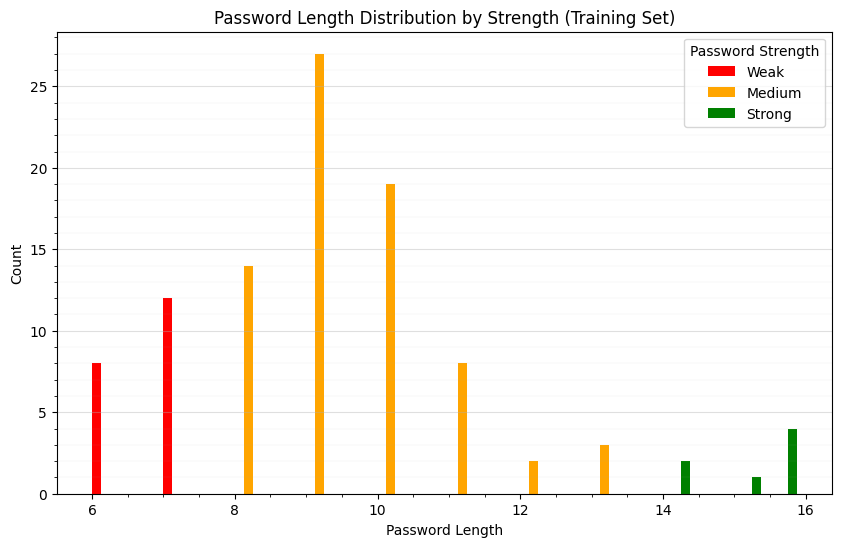

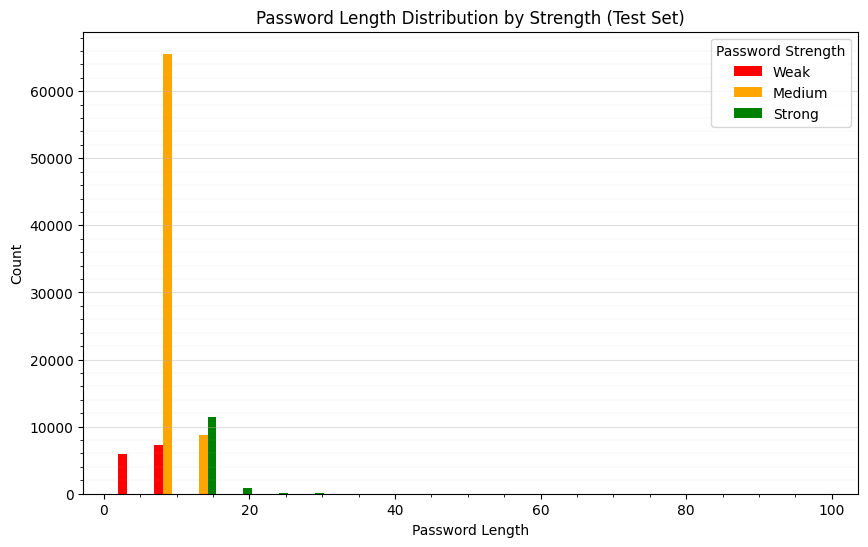

In [22]:
import matplotlib.pyplot as plt


def plot_dataset(x, y, bins=20, title="Password Length Distribution by Strength"):
    """
    Plots the distribution of password lengths grouped by strength as grouped bars.
    x: feature matrix (password length should be the first column)
    y: strength labels
    """
    plt.figure(figsize=(10, 6))
    classes = np.unique(y)
    colors = ["red", "orange", "green", "blue", "purple", "cyan", "magenta"]
    all_lengths = x[:, 0]
    bin_edges = np.histogram_bin_edges(all_lengths, bins=bins)
    width = (bin_edges[1] - bin_edges[0]) / (len(classes) + 1)
    legend_names = ["Weak", "Medium", "Strong"]
    for i, k in enumerate(classes):
        lengths = x[y == k, 0]
        hist, _ = np.histogram(lengths, bins=bin_edges)
        plt.bar(
            bin_edges[:-1] + i * width,
            hist,
            width=width,
            color=colors[i % len(colors)],
            align="edge",
            label=legend_names[i],
        )

    plt.xlabel("Password Length")
    plt.ylabel("Count")
    plt.title(title)
    plt.legend(title="Password Strength")
    plt.grid(axis="y", alpha=0.4)
    plt.minorticks_on()  # Enable minor ticks
    plt.grid(which="minor", axis="y", alpha=0.2, linewidth=0.3)  # Minor grid
    plt.show()


plot_dataset(xtr, ytr, title="Password Length Distribution by Strength (Training Set)")
plot_dataset(xts, yts, title="Password Length Distribution by Strength (Test Set)")

In [23]:
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

# Define the classifiers
KNN_clf = KNeighborsClassifier(n_neighbors=6)
SVM_clf = SVC(kernel="rbf")
DT_clf = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=0)
DT_reg = DecisionTreeRegressor()
GNB_clf = GaussianNB()
SGD_reg = SGDClassifier(loss="hinge", penalty="l2")

# List of classifiers to be trained and tested
clfs = [KNN_clf, SVM_clf, DT_clf, DT_reg, GNB_clf, SGD_reg]



---	KNeighborsClassifier(n_neighbors=6)	---
Training time:	 0.0011 seconds
Prediction time: 3.2419 seconds
Accuracy score:	 0.9846


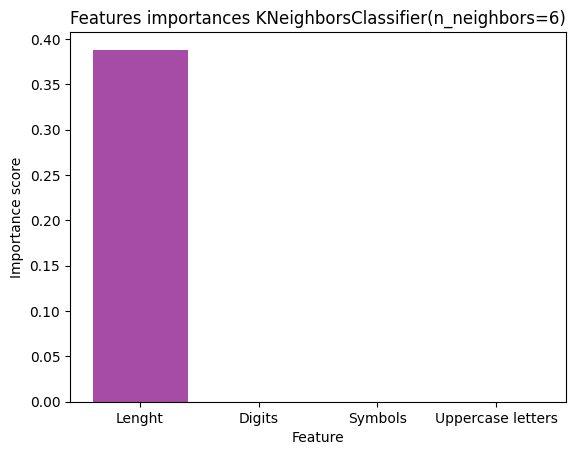

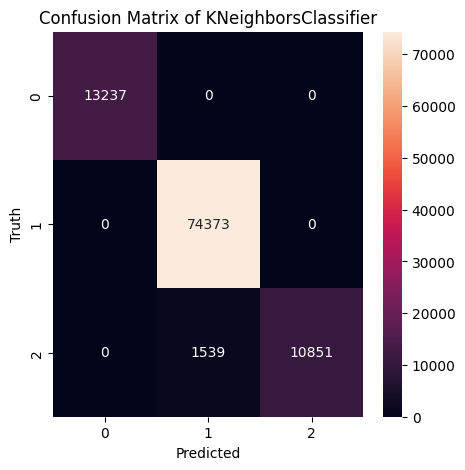



---	SVC()	---
Training time:	 0.0012 seconds
Prediction time: 0.4952 seconds
Accuracy score:	 1.0000


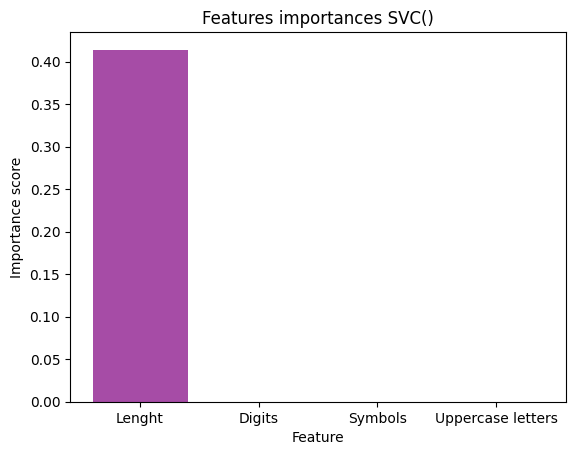

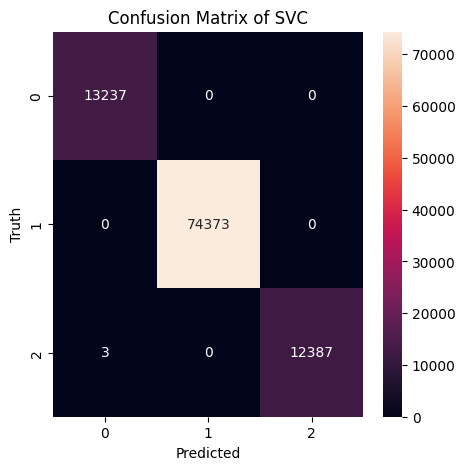



---	DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0)	---
Training time:	 0.0009 seconds
Prediction time: 0.0040 seconds
Accuracy score:	 0.9616


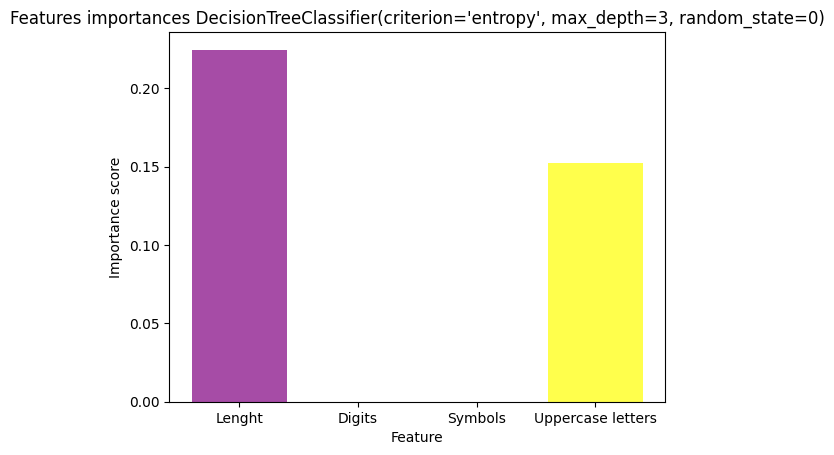

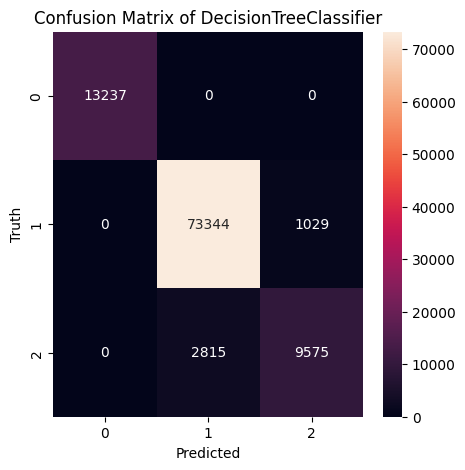



---	DecisionTreeRegressor()	---
Training time:	 0.0005 seconds
Prediction time: 0.0021 seconds
Accuracy score:	 0.9616


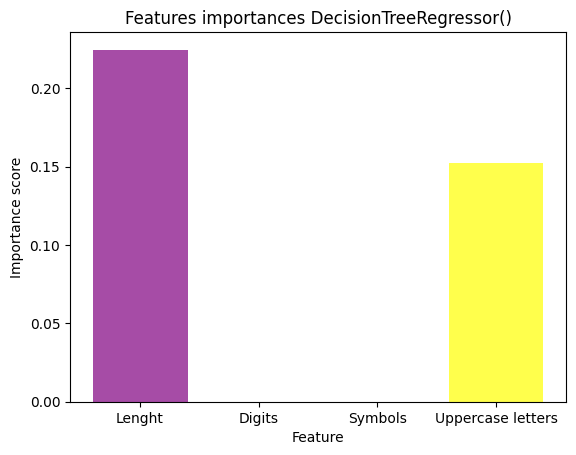

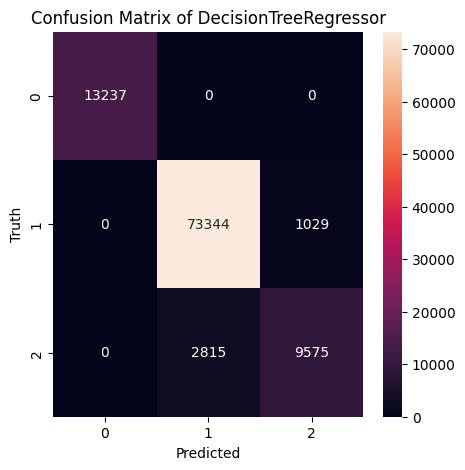



---	GaussianNB()	---
Training time:	 0.0008 seconds
Prediction time: 0.0083 seconds
Accuracy score:	 0.8372


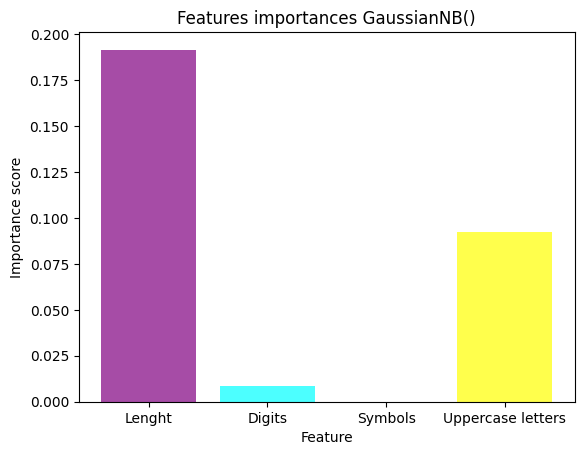

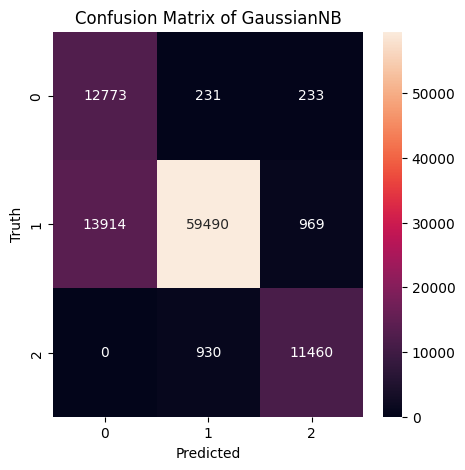



---	SGDClassifier()	---
Training time:	 0.0022 seconds
Prediction time: 0.0040 seconds
Accuracy score:	 0.8703


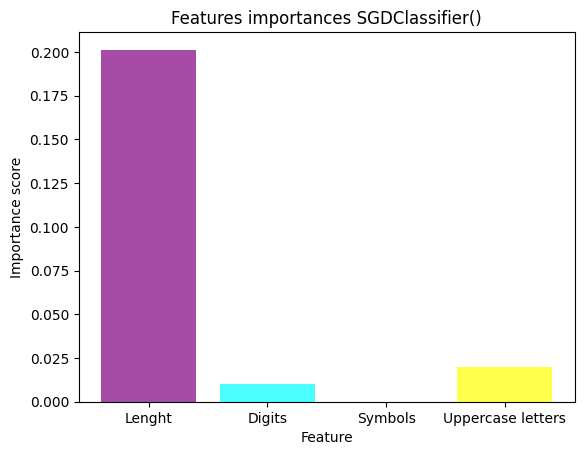

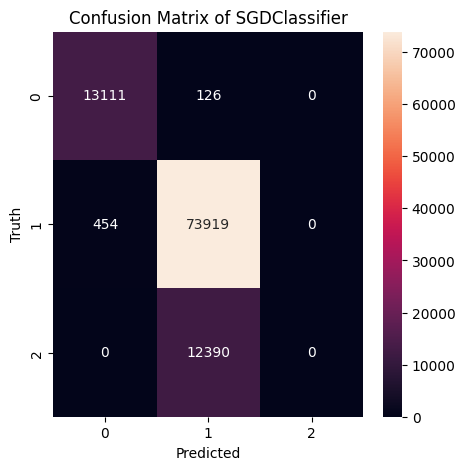

In [24]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score
import time


# Function to plot the confusion matrix
def plot_confusion_matrix(y_test, y_pred, classifier_name):
    plt.figure(figsize=(5, 5))
    plt.title("Confusion Matrix of " + classifier_name)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d")
    plt.xlabel("Predicted")
    plt.ylabel("Truth")
    plt.show()


def feature_importance_histogram(importances, title=None):
    colors = ["purple", "cyan", "lightgreen", "yellow", "black"]

    plt.bar(
        [x for x in range(len(importances))],
        importances,
        tick_label=[x for x in range(len(importances))],
        color=colors,
        linewidth=1.2,
        alpha=0.7,
    )
    plt.xlabel("Feature")
    plt.ylabel("Importance score")
    plt.xticks([0, 1, 2, 3], ["Lenght", "Digits", "Symbols", "Uppercase letters"])
    plt.title(title)
    plt.show()


# Histogram of the features and accuracy
for clf in clfs:

    # For every classifier, plot the feature importance histogram...
    print("\n")
    print(f"---\t{clf}\t---")
    tic = time.perf_counter()
    clf.fit(xtr, ytr)
    toc = time.perf_counter()
    print(f"Training time:\t {toc-tic:.4f} seconds")

    tic = time.perf_counter()
    predictions = clf.predict(xts)
    toc = time.perf_counter()
    print(f"Prediction time: {toc-tic:.4f} seconds")

    print(f"Accuracy score:\t {accuracy_score(yts, predictions):.4f}")

    results = permutation_importance(clf, xts, yts, scoring="accuracy")
    importances = results.importances_mean

    feature_importance_histogram(importances, title=f"Features importances {clf}")
    plot_confusion_matrix(yts, predictions, clf.__class__.__name__)